In [41]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import itertools
from scipy import stats
import matplotlib.pyplot as plt

In [42]:
input_file = 'india_monthly_exports_with_indicators.xlsx'

df = pd.read_excel(input_file, sheet_name='Complete Data')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

monthly = (df.groupby('Date')
             .agg(Export_Value   = ('Export_Value',   'sum'),
                  GDP_Growth      = ('gdp_growth',      'first'),
                  Inflation_Rate = ('Inflation_rate',  'first'),
                  REER           = ('REER',            'first'))
             .reset_index()
             .sort_values('Date'))
monthly.set_index('Date', inplace=True)
monthly.index = pd.DatetimeIndex(monthly.index).to_period('M')

print("RAW DATA SUMMARY")
print(f" Observations : {len(monthly)}")
print(f" Date range   : {monthly.index[0]} to {monthly.index[-1]}")
print(f" NaN counts   : {dict(monthly.isnull().sum())}")

RAW DATA SUMMARY
 Observations : 96
 Date range   : 2018-01 to 2025-12
 NaN counts   : {'Export_Value': np.int64(0), 'GDP_Growth': np.int64(0), 'Inflation_Rate': np.int64(0), 'REER': np.int64(0)}


### Interpolation of GDP

In [43]:
# INTERPOLATE QUARTERLY GDP growth VALUES TO MONTHLY
monthly['GDP_Growth'] = (
    monthly['GDP_Growth']
    .where(monthly['GDP_Growth'] != monthly['GDP_Growth'].shift(1))
    .interpolate(method='linear')
)

print("INTERPOLATED DATA SUMMARY")
print(f"nan : {monthly['GDP_Growth'].isnull().sum()}")
print(f"\n  First 6 months of GDP Growth after interpolation:")
for idx, val in monthly['GDP_Growth'].head(6).items():
    print(f"{idx}:{val:.4f}")


INTERPOLATED DATA SUMMARY
nan : 0

  First 6 months of GDP Growth after interpolation:
2018-01:7.7000
2018-02:7.7667
2018-03:7.8333
2018-04:7.9000
2018-05:7.6333
2018-06:7.3667


### Data Stationary check

In [44]:
#ADF TEST FUNCTION
def run_adf(series, label, alpha=0.05):
    clean = series.dropna()
    stat, pval, lags, nobs, crit, _ = adfuller(clean, autolag='AIC')
    stationary = pval < alpha
    status  = "STATIONARY" if stationary else "NON-STATIONARY"
    bracket = f"(p={pval:.4f} < alpha={alpha})" if stationary else f"(p={pval:.4f} >= alpha={alpha})"

    print(f"\n Variable: {label}")
    print(f" Series length: {len(clean)}")
    print(f"ADF Statistic: {stat:.6f}")
    print(f"p-value: {pval:.6f}")
    print(f"Lags used: {lags}")
    print(f"Critical vals: 1% {crit['1%']:.4f}|5% {crit['5%']:.4f}|10% {crit['10%']:.4f}")
    print(f"Decision: {status} {bracket}")

    return stationary, pval, lags, nobs


stat_exp,_, _, _ = run_adf(monthly['Export_Value'],'Export_Value(Level)')
stat_gdp,_, _, _ = run_adf(monthly['GDP_Growth'],'GDP_Growth(Level)')
stat_inf,_, _, _ = run_adf(monthly['Inflation_Rate'],'Inflation_Rate(Level)')
stat_reer,_, _, _ = run_adf(monthly['REER'],'REER (Level)')


 Variable: Export_Value(Level)
 Series length: 96
ADF Statistic: -2.015150
p-value: 0.279970
Lags used: 1
Critical vals: 1% -3.5019|5% -2.8928|10% -2.5835
Decision: NON-STATIONARY (p=0.2800 >= alpha=0.05)

 Variable: GDP_Growth(Level)
 Series length: 96
ADF Statistic: -3.902032
p-value: 0.002020
Lags used: 4
Critical vals: 1% -3.5043|5% -2.8939|10% -2.5840
Decision: STATIONARY (p=0.0020 < alpha=0.05)

 Variable: Inflation_Rate(Level)
 Series length: 96
ADF Statistic: -1.577302
p-value: 0.494985
Lags used: 12
Critical vals: 1% -3.5117|5% -2.8970|10% -2.5857
Decision: NON-STATIONARY (p=0.4950 >= alpha=0.05)

 Variable: REER (Level)
 Series length: 96
ADF Statistic: -2.591507
p-value: 0.094765
Lags used: 1
Critical vals: 1% -3.5019|5% -2.8928|10% -2.5835
Decision: NON-STATIONARY (p=0.0948 >= alpha=0.05)


In [45]:
# adf on differenced export values
d_order = 0
stat_exp_d1 = stat_exp_d2 = False

if stat_exp:
    d_order = 0
    print("\nExport_Value is stationary at level I(0), d = 0")
else:
    print("\n  Export_Value non-stationary at level,testing 1st difference")
    stat_exp_d1, _, _, _ = run_adf(
        monthly['Export_Value'].diff(), 'Export_Value (1st Difference)'
    )
    if stat_exp_d1:
        d_order = 1
    else:
        print("\n Still non-stationary,testing 2nd difference")
        stat_exp_d2, _, _, _ = run_adf(
            monthly['Export_Value'].diff().diff(), 'Export_Value (2nd Difference)'
        )
        if stat_exp_d2:
            d_order = 2
        else:
            print(" 2nd difference still non-stationary")

print(f"\nExport_Value is I({d_order})|d_order = {d_order}")

# adf on differenced exogeneous variables
stat_inf_d1,  _, _, _ = run_adf(
    monthly['Inflation_Rate'].diff(), 'Inflation_Rate (1st Difference)'
)
stat_reer_d1, _, _, _ = run_adf(
    monthly['REER'].diff(),'REER(1st Difference)'
)


  Export_Value non-stationary at level,testing 1st difference

 Variable: Export_Value (1st Difference)
 Series length: 95
ADF Statistic: -9.628958
p-value: 0.000000
Lags used: 1
Critical vals: 1% -3.5027|5% -2.8932|10% -2.5836
Decision: STATIONARY (p=0.0000 < alpha=0.05)

Export_Value is I(1)|d_order = 1

 Variable: Inflation_Rate (1st Difference)
 Series length: 95
ADF Statistic: -3.297942
p-value: 0.014971
Lags used: 11
Critical vals: 1% -3.5117|5% -2.8970|10% -2.5857
Decision: STATIONARY (p=0.0150 < alpha=0.05)

 Variable: REER(1st Difference)
 Series length: 95
ADF Statistic: -8.822451
p-value: 0.000000
Lags used: 0
Critical vals: 1% -3.5019|5% -2.8928|10% -2.5835
Decision: STATIONARY (p=0.0000 < alpha=0.05)


In [46]:
export_d1 = monthly['Export_Value'].diff()
gdp_lvl   = monthly['GDP_Growth']
inf_d1    = monthly['Inflation_Rate'].diff()
reer_d1   = monthly['REER'].diff()

data_ready = pd.concat(
    [export_d1, gdp_lvl, inf_d1, reer_d1], axis=1
)
data_ready.columns = ['Export_d1', 'GDP_level', 'Inflation_d1', 'REER_d1']
data_ready = data_ready.dropna()

# DATA SPLIT

In [47]:
Y    = data_ready['Export_d1']
exog = data_ready[['GDP_level', 'Inflation_d1', 'REER_d1']]

In [48]:
N_TEST = 12
Y_train = Y.iloc[:-N_TEST]
Y_test  = Y.iloc[-N_TEST:]
X_train = exog.iloc[:-N_TEST]
X_test  = exog.iloc[-N_TEST:]

export_level = monthly['Export_Value']

# GRID SEARCH ON TRANING SET FOR BEST MODEL


In [49]:
print("GRID SEARCH  (trained data 2018-02 to 2024-12)")


results = []
for p, q in itertools.product(range(0, 4), range(0, 4)):
    try:
        fit = SARIMAX(
            Y_train, exog=X_train,
            order=(p, 0, q),
            trend='n',
            enforce_stationarity=True,
            enforce_invertibility=True
        ).fit(disp=False)
        results.append({
            'p': p, 'q': q,
            'AIC': round(fit.aic, 2),
            'BIC': round(fit.bic, 2),
            'HQIC': round(fit.hqic, 2),
            'LogLik': round(fit.llf, 2),
            'Converged': True
        })
        print(f"  ARIMAX({p},0,{q})  AIC={fit.aic:>10.2f}  BIC={fit.bic:>10.2f}")
    except Exception as e:
        results.append({'p': p, 'q': q, 'AIC': np.nan, 'BIC': np.nan,
                        'HQIC': np.nan, 'LogLik': np.nan, 'Converged': False})
        print(f"  ARIMAX({p},0,{q})  FAILED: {str(e)[:50]}")

grid_df  = (pd.DataFrame(results)
              .dropna(subset=['AIC'])
              .sort_values('AIC')
              .reset_index(drop=True))

best_p = int(grid_df.iloc[0].p)
best_q = int(grid_df.iloc[0].q)

print(f"\nTop 5 models:")
print(grid_df.head(5).to_string(index=False))
print(f"\nSelected: ARIMAX({best_p}, 0, {best_q})  "
      f"AIC={grid_df.iloc[0].AIC}  BIC={grid_df.iloc[0].BIC}")

GRID SEARCH  (trained data 2018-02 to 2024-12)
  ARIMAX(0,0,0)  AIC=   1600.76  BIC=   1610.44
  ARIMAX(0,0,1)  AIC=   1582.02  BIC=   1594.12
  ARIMAX(0,0,2)  AIC=   1583.50  BIC=   1598.01
  ARIMAX(0,0,3)  AIC=   1585.43  BIC=   1602.36
  ARIMAX(1,0,0)  AIC=   1585.04  BIC=   1597.14
  ARIMAX(1,0,1)  AIC=   1583.35  BIC=   1597.86
  ARIMAX(1,0,2)  AIC=   1585.43  BIC=   1602.36
  ARIMAX(1,0,3)  AIC=   1586.47  BIC=   1605.82
  ARIMAX(2,0,0)  AIC=   1581.62  BIC=   1596.13
  ARIMAX(2,0,1)  AIC=   1583.10  BIC=   1600.04
  ARIMAX(2,0,2)  AIC=   1584.54  BIC=   1603.89
  ARIMAX(2,0,3)  AIC=   1583.17  BIC=   1604.94
  ARIMAX(3,0,0)  AIC=   1582.90  BIC=   1599.83
  ARIMAX(3,0,1)  AIC=   1584.92  BIC=   1604.27
  ARIMAX(3,0,2)  AIC=   1583.46  BIC=   1605.23
  ARIMAX(3,0,3)  AIC=   1586.12  BIC=   1610.30

Top 5 models:
 p  q     AIC     BIC    HQIC  LogLik  Converged
 2  0 1581.62 1596.13 1587.45 -784.81       True
 0  1 1582.02 1594.12 1586.88 -786.01       True
 3  0 1582.90 1599.83 1

In [50]:
train_model = SARIMAX(
    Y_train, exog=X_train,
    order=(best_p, 0, best_q),
    trend='n',
    enforce_stationarity=True,
    enforce_invertibility=True
).fit(disp=False)

print("TRAIN-ONLY MODEL SUMMARY")
print(train_model.summary())

TRAIN-ONLY MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:              Export_d1   No. Observations:                   83
Model:               SARIMAX(2, 0, 0)   Log Likelihood                -784.809
Date:                Thu, 23 Apr 2026   AIC                           1581.619
Time:                        09:54:14   BIC                           1596.132
Sample:                    02-28-2018   HQIC                          1587.449
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
GDP_level       53.6825     25.906      2.072      0.038       2.907     104.458
Inflation_d1  1076.5331    529.921      2.031      0.042      37.907    2115.159
REER_d1       -483.

# MODEL VALIDATION

# TRAIN SAMPLE ACCURACY

In [51]:
fitted_diff = train_model.fittedvalues
prev_lvl    = export_level.shift(1)
common_idx  = fitted_diff.index.intersection(prev_lvl.dropna().index)

y_true_is   = export_level.loc[common_idx].values
y_pred_is   = (prev_lvl.loc[common_idx] + fitted_diff.loc[common_idx]).values

rmse_is = np.sqrt(mean_squared_error(y_true_is, y_pred_is))
mae_is  = mean_absolute_error(y_true_is, y_pred_is)
mape_is = np.mean(np.abs((y_true_is - y_pred_is) / y_true_is)) * 100
r2_is   = 1 - np.sum((y_true_is - y_pred_is) ** 2) / np.sum(
              (y_true_is - y_true_is.mean()) ** 2)

print(f"  RMSE : {rmse_is:>10.2f}  USD M")
print(f"  MAE  : {mae_is:>10.2f}  USD M")
print(f"  MAPE : {mape_is:>10.2f}  %")
print(f"  R²   : {r2_is:>10.4f}")

  RMSE :    3086.13  USD M
  MAE  :    2484.01  USD M
  MAPE :       9.04  %
  R²   :     0.7577


# TEST SAMPLE ACCURACY

In [52]:
USE_ROLLING = True
if USE_ROLLING:
    osa_pred_diff  = []
    osa_pred_level = []

    for i in range(N_TEST):
        # Expand training window by i steps
        Y_roll = Y.iloc[:-(N_TEST - i)]          # up to but not including test[i]
        X_roll = exog.iloc[:-(N_TEST - i)]

        model_roll = SARIMAX(
            Y_roll, exog=X_roll,
            order=(best_p, 0, best_q),
            trend='n',
            enforce_stationarity=True,
            enforce_invertibility=True
        ).fit(disp=False)

        # One step forecast with actual exog for that step
        fc = model_roll.get_forecast(steps=1, exog=X_test.iloc[[i]])
        pred_d = fc.predicted_mean.values[0]

        # Level reconstruction: prev actual level + predicted diff
        prev_actual_level = export_level.iloc[-(N_TEST + 1 - i)]  # true t-1 level
        pred_level = prev_actual_level + pred_d

        osa_pred_diff.append(pred_d)
        osa_pred_level.append(pred_level)


    actual_lvl_test = export_level.iloc[-N_TEST:].values
    osa_pred_level  = np.array(osa_pred_level)

    rmse_osa = np.sqrt(mean_squared_error(actual_lvl_test, osa_pred_level))
    mae_osa  = mean_absolute_error(actual_lvl_test, osa_pred_level)
    mape_osa = np.mean(np.abs((actual_lvl_test - osa_pred_level) / actual_lvl_test)) * 100

print(f"\nOne-Step-Ahead OOS (2025, rolling window, n={N_TEST}):")
print(f"  RMSE : {rmse_osa:>10.2f}  USD M")
print(f"  MAE  : {mae_osa:>10.2f}  USD M")
print(f"  MAPE : {mape_osa:>10.2f}  %")



One-Step-Ahead OOS (2025, rolling window, n=12):
  RMSE :    2319.67  USD M
  MAE  :    1695.79  USD M
  MAPE :       4.58  %


# PREDICTED Vs ACTUAL

In [53]:
print(f"\n{'Month':<12} {'Actual':>14} {'Predicted':>12} {'Error':>10}")
for i, idx in enumerate(Y_test.index):
        err = actual_lvl_test[i] - osa_pred_level[i]
        print(f"  {str(idx):<12} {actual_lvl_test[i]:>14.2f} "
              f"{osa_pred_level[i]:>12.2f} {err:>+10.2f}")


Month                Actual    Predicted      Error
  2025-01            36338.46     36975.30    -636.84
  2025-02            36910.95     36734.82    +176.13
  2025-03            42047.58     37903.81   +4143.77
  2025-04            38283.21     39714.89   -1431.68
  2025-05            38303.31     39472.43   -1169.12
  2025-06            34969.76     39772.65   -4802.89
  2025-07            37017.55     36752.23    +265.32
  2025-08            34770.55     38078.62   -3308.07
  2025-09            36132.77     36412.93    -280.16
  2025-10            34105.71     35500.66   -1394.95
  2025-11            37908.48     35180.76   +2727.72
  2025-12            38468.38     38455.61     +12.77


# MODEL FIT TO FULL DATA

In [54]:
print("FINAL MODEL — REFIT ON FULL DATA (2018-02 → 2025-12)")

final_model = SARIMAX(
    Y, exog=exog,
    order=(best_p, 0, best_q),
    trend='n',
    enforce_stationarity=True,
    enforce_invertibility=True
).fit(disp=False)

print(final_model.summary())

FINAL MODEL — REFIT ON FULL DATA (2018-02 → 2025-12)
                               SARIMAX Results                                
Dep. Variable:              Export_d1   No. Observations:                   95
Model:               SARIMAX(2, 0, 0)   Log Likelihood                -895.655
Date:                Thu, 23 Apr 2026   AIC                           1803.310
Time:                        09:54:15   BIC                           1818.634
Sample:                    02-28-2018   HQIC                          1809.502
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
GDP_level       49.4704     23.227      2.130      0.033       3.947      94.994
Inflation_d1  1083.3164    477.667      2.268      0.023     147.106    

# Forecast

In [55]:
last_gdp = monthly['GDP_Growth'].iloc[-1]
fut_exog = pd.DataFrame({
    'GDP_level'   : [last_gdp] * 12,
    'Inflation_d1': [0.0] * 12,   # Inflation level assumed flat
    'REER_d1'     : [0.0] * 12    # REER level assumed flat
})
fut_fc  = final_model.get_forecast(steps=12, exog=fut_exog)
fut_d   = fut_fc.predicted_mean
fut_ci  = fut_fc.conf_int(alpha=0.05)

In [56]:
last_export = export_level.iloc[-1]

# Iterative level: level[t] = level[t-1] + predicted_diff[t]
# This equals: last_export + cumsum(fut_d)
fut_level = last_export + fut_d.cumsum()

# CI propagation: lower/upper also via cumsum of CI bounds
fut_lo = last_export + fut_ci.iloc[:, 0].cumsum()
fut_hi = last_export + fut_ci.iloc[:, 1].cumsum()

fut_idx = pd.period_range(start=monthly.index[-1] + 1, periods=12, freq='M')

print(f"\n{'Month':<12} {'Forecast (USD M)':>16} {'Lower 95%':>14} {'Upper 95%':>12}")

for i, p in enumerate(fut_idx):
    print(f"  {str(p):<12} {fut_level.iloc[i]:>16.2f} "
          f"{fut_lo.iloc[i]:>14.2f} {fut_hi.iloc[i]:>12.2f}")


Month        Forecast (USD M)      Lower 95%    Upper 95%
  2026-01              38828.41       32895.61     44761.21
  2026-02              39536.91       26840.83     52232.99
  2026-03              39734.81       20267.88     59201.73
  2026-04              40126.57       13860.24     66392.90
  2026-05              40537.65        7459.00     73616.29
  2026-06              40890.53         999.13     80781.93
  2026-07              41270.52       -5433.90     87974.94
  2026-08              41649.97      -11867.67     95167.62
  2026-09              42023.06      -18307.82    102353.94
  2026-10              42399.76      -24744.36    109543.88
  2026-11              42776.05      -31181.32    116733.41
  2026-12              43151.67      -37618.93    123922.28


VISUALIZATION

In [57]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from statsmodels.graphics.tsaplots import acf, pacf

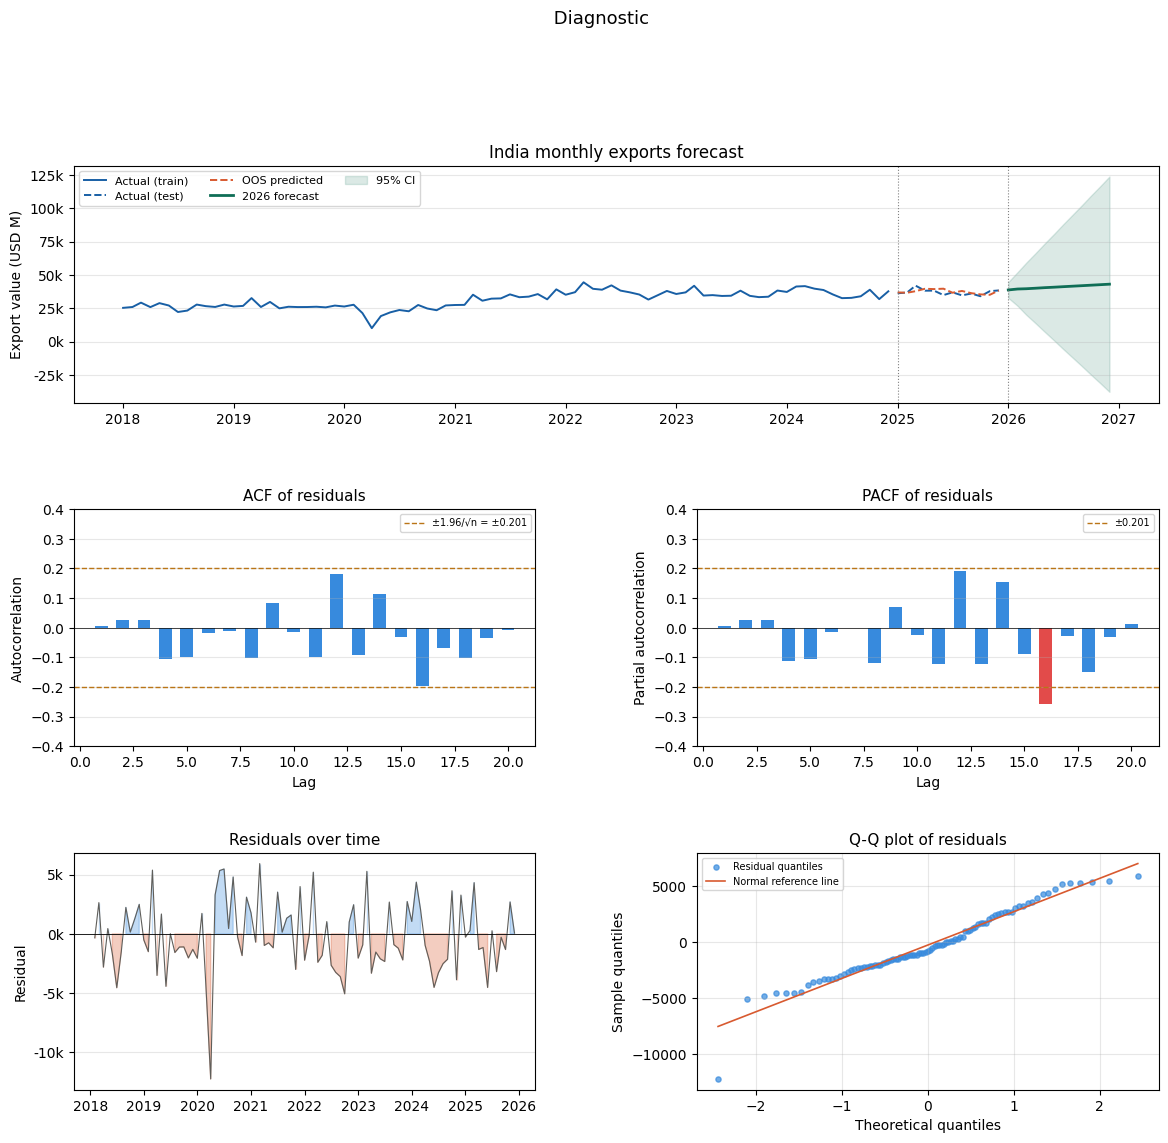

In [58]:

fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax_fc  = fig.add_subplot(gs[0, :])   # forecast
ax_acf = fig.add_subplot(gs[1, 0])   # ACF
ax_pac = fig.add_subplot(gs[1, 1])   # PACF
ax_res = fig.add_subplot(gs[2, 0])   # residual time series
ax_qq  = fig.add_subplot(gs[2, 1])   # Q-Q plot

# Forecast

train_idx = monthly.index[:-12]
test_idx  = monthly.index[-12:]

train_vals    = monthly['Export_Value'].loc[train_idx]
test_actual   = monthly['Export_Value'].loc[test_idx]


def to_ts(pidx):
    return pidx.to_timestamp()

ax_fc.plot(to_ts(train_idx), train_vals.values,
           color='#185FA5', lw=1.4, label='Actual (train)')
ax_fc.plot(to_ts(test_idx), test_actual.values,
           color='#185FA5', lw=1.4, ls='--', label='Actual (test)')
ax_fc.plot(to_ts(test_idx), osa_pred_level,
           color='#D85A30', lw=1.4, ls='--', label='OOS predicted')

future_ts = fut_idx.to_timestamp()
ax_fc.plot(future_ts, fut_level.values,
           color='#0F6E56', lw=2, label='2026 forecast')
ax_fc.fill_between(future_ts, fut_lo.values, fut_hi.values,
                   color='#0F6E56', alpha=0.15, label='95% CI')

ax_fc.axvline(to_ts(test_idx)[0], color='gray', lw=0.8, ls=':')
ax_fc.axvline(future_ts[0],       color='gray', lw=0.8, ls=':')
ax_fc.set_title('India monthly exports forecast', fontsize=12)
ax_fc.set_ylabel('Export value (USD M)')
ax_fc.legend(fontsize=8, ncol=3)
ax_fc.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax_fc.grid(axis='y', alpha=0.3)

# ACF

resid = final_model.resid.dropna()
n_obs = len(resid)
nlags = 20
ci_bound = 1.96 / np.sqrt(n_obs)

acf_vals  = acf(resid,  nlags=nlags, fft=True)[1:]   # skip lag-0
pacf_vals = pacf(resid, nlags=nlags)[1:]

lags = np.arange(1, nlags + 1)

colors_acf  = ['#E24B4A' if abs(v) > ci_bound else '#378ADD' for v in acf_vals]
colors_pacf = ['#E24B4A' if abs(v) > ci_bound else '#378ADD' for v in pacf_vals]

ax_acf.bar(lags, acf_vals, color=colors_acf, width=0.6)
ax_acf.axhline( ci_bound, color='#BA7517', lw=1, ls='--', label=f'±1.96/√n = ±{ci_bound:.3f}')
ax_acf.axhline(-ci_bound, color='#BA7517', lw=1, ls='--')
ax_acf.axhline(0, color='black', lw=0.5)
ax_acf.set_title('ACF of residuals', fontsize=11)
ax_acf.set_xlabel('Lag')
ax_acf.set_ylabel('Autocorrelation')
ax_acf.set_ylim(-0.4, 0.4)
ax_acf.legend(fontsize=7)
ax_acf.grid(axis='y', alpha=0.3)

n_sig_acf = sum(abs(v) > ci_bound for v in acf_vals)


# PACF

ax_pac.bar(lags, pacf_vals, color=colors_pacf, width=0.6)
ax_pac.axhline( ci_bound, color='#BA7517', lw=1, ls='--', label=f'±{ci_bound:.3f}')
ax_pac.axhline(-ci_bound, color='#BA7517', lw=1, ls='--')
ax_pac.axhline(0, color='black', lw=0.5)
ax_pac.set_title('PACF of residuals', fontsize=11)
ax_pac.set_xlabel('Lag')
ax_pac.set_ylabel('Partial autocorrelation')
ax_pac.set_ylim(-0.4, 0.4)
ax_pac.legend(fontsize=7)
ax_pac.grid(axis='y', alpha=0.3)

n_sig_pacf = sum(abs(v) > ci_bound for v in pacf_vals)


# Residual time series

resid_ts = to_ts(resid.index)

ax_res.plot(resid_ts, resid.values, color='#5F5E5A', lw=0.8)
ax_res.axhline(0, color='black', lw=0.6)
ax_res.fill_between(resid_ts, resid.values, 0,
                    where=(resid.values > 0), color='#378ADD', alpha=0.3)
ax_res.fill_between(resid_ts, resid.values, 0,
                    where=(resid.values < 0), color='#D85A30', alpha=0.3)
ax_res.set_title('Residuals over time', fontsize=11)
ax_res.set_ylabel('Residual')
ax_res.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax_res.grid(axis='y', alpha=0.3)

# Q-Q

from scipy import stats as scipy_stats

(osm, osr), (slope, intercept, r) = scipy_stats.probplot(resid.values, dist='norm')
ax_qq.scatter(osm, osr, s=14, color='#378ADD', alpha=0.7, label='Residual quantiles')
ax_qq.plot(osm, slope * np.array(osm) + intercept,
           color='#D85A30', lw=1.2, label='Normal reference line')
ax_qq.set_title('Q-Q plot of residuals', fontsize=11)
ax_qq.set_xlabel('Theoretical quantiles')
ax_qq.set_ylabel('Sample quantiles')
ax_qq.legend(fontsize=7)
ax_qq.grid(alpha=0.3)


fig.suptitle(' Diagnostic', fontsize=13, y=1.01)
plt.show()
